[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/takechanman1228/marketing-science-in-python/blob/main/notebooks/part3-causal-inference/sec3.3_quasi_experiments.ipynb)

# Estimation code for §3.3 "Quasi Experiments"

The chapter puts three quasi-experimental designs on one problem: a retailer with
100 stores rolled out a new in-store display, and the way the display was assigned
picks the design. This notebook shows how to *estimate* each one in Python, in the
chapter's order, on small synthetic datasets where we plant a known effect and check
that the estimator recovers it:

- **Regression Discontinuity (RDD)** — a local linear regression around a cutoff.
  The chapter's store version (every store above $1M gets the display) leaves too
  few stores near the line, so this notebook runs the customer version the chapter
  pivots to: a coupon for customers with at least $500 of past spend.
- **Difference-in-Differences (DiD)** — the by-hand 2×2 table, then the same estimate
  from a regression on 24 months × 100 stores with store and month fixed effects and a
  clustered standard error, and an event-study check of the parallel-trends assumption.
- **Synthetic Control** — only the New York store got the display; the other 99 stores
  form the donor pool, and convex weights fit on the pre-period build a synthetic
  New York.

Everything runs on `statsmodels` + `scipy`, which ship with the book environment —
no specialized causal-inference library required. The figures in the chapter itself
are produced by the separate `sec3.3_quasi_experiment_figures.ipynb` notebook; this
one is about estimation, so its plots are inline only.

### Setup

In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.optimize import minimize
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. Regression Discontinuity

Customers with at least $500 in pre-campaign annual spend receive a coupon. Customers
just above and just below the cutoff are otherwise nearly identical, so the jump in
subsequent spend right at the threshold estimates the local effect of the coupon.
(With 100 stores and a $1M cutoff, only a handful of stores sit near the line; with
thousands of customers near $500, RDD has something to work with.)

We plant a **true jump of $60** and estimate it with a *local linear regression*:
keep only customers within a bandwidth of the cutoff, center the running variable at
the cutoff, and fit `y ~ treated + x_centered + treated:x_centered`. Centering makes
the `treated` coefficient the gap *at the cutoff*; the interaction lets the slope
differ on each side. We restrict to a bandwidth because RDD identifies an effect
*local* to the threshold — points far away carry little information about the jump and
can bias a global fit.

In [2]:
rng = np.random.default_rng(7)

CUTOFF = 500
TRUE_JUMP = 60.0
spend = rng.uniform(200, 800, 2000)              # running variable: annual spend
coupon = (spend >= CUTOFF).astype(int)
subsequent = 100 + 0.45 * spend + TRUE_JUMP * coupon + rng.normal(0, 18, spend.size)

rdd = pd.DataFrame({"spend": spend, "coupon": coupon, "subsequent": subsequent})
rdd["x_centered"] = rdd["spend"] - CUTOFF

BANDWIDTH = 100
window = rdd[rdd["x_centered"].abs() <= BANDWIDTH]

rdd_model = smf.ols("subsequent ~ coupon + x_centered + coupon:x_centered", data=window).fit()
rdd_estimate = rdd_model.params["coupon"]
print(f"RDD local estimate at cutoff: ${rdd_estimate:.1f}  "
      f"(SE {rdd_model.bse['coupon']:.1f}, true jump ${TRUE_JUMP:.0f}, "
      f"n={len(window)} within ±${BANDWIDTH})")

RDD local estimate at cutoff: $61.1  (SE 2.7, true jump $60, n=654 within ±$100)


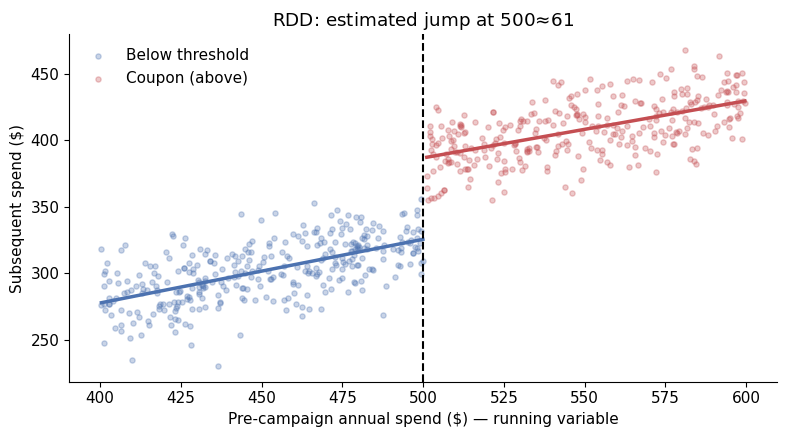

In [3]:
# Visualize the discontinuity with a fitted line on each side of the cutoff.
fig, ax = plt.subplots(figsize=(8, 4.5))
for mask, color, label in [(window["coupon"] == 0, "#4C72B0", "Below threshold"),
                           (window["coupon"] == 1, "#C44E52", "Coupon (above)")]:
    side = window[mask]
    ax.scatter(side["spend"], side["subsequent"], color=color, alpha=0.3, s=14, label=label)
    b, a = np.polyfit(side["spend"], side["subsequent"], 1)
    xs = np.linspace(side["spend"].min(), side["spend"].max(), 50)
    ax.plot(xs, a + b * xs, color=color, lw=2.5)
ax.axvline(CUTOFF, color="black", ls="--", lw=1.5)
ax.set_xlabel("Pre-campaign annual spend ($) — running variable")
ax.set_ylabel("Subsequent spend ($)")
ax.set_title(f"RDD: estimated jump at $500 ≈ ${rdd_estimate:.0f}")
ax.legend(loc="upper left", frameon=False)
fig.tight_layout()

A histogram of the running variable is the manipulation check the chapter describes:
if customers could push themselves over $500, there would be a pile just above the
cutoff. Here the running variable is uniform, so the two bins straddling the cutoff
hold about the same number of customers.

In [4]:
just_below = ((rdd["spend"] >= CUTOFF - 25) & (rdd["spend"] < CUTOFF)).sum()
just_above = ((rdd["spend"] >= CUTOFF) & (rdd["spend"] < CUTOFF + 25)).sum()
print(f"Customers within $25 below the cutoff: {just_below};  within $25 above: {just_above}")

Customers within $25 below the cutoff: 89;  within $25 above: 85


## 2. Difference-in-Differences

### 2a. The estimate by hand

The sales team picked 50 stores for the display and 50 comparable stores kept the
standard shelf. DiD is two subtractions: how much the pilot stores changed, minus how
much the comparison stores changed over the same window. The comparison change is our
estimate of what the pilot stores *would* have done anyway (seasonality, traffic, a
competitor's stockout), so subtracting it leaves the incremental effect. These are the
chapter's numbers.

In [5]:
did = pd.DataFrame({
    "group":  ["Pilot stores", "Comparison stores"],
    "before": [42, 40],   # category sales per store, $k
    "after":  [48, 43],
})
did["change"] = did["after"] - did["before"]
did_estimate = did.loc[0, "change"] - did.loc[1, "change"]

print(did)
print(f"\nDiD estimate: ${did_estimate:.0f}k")   # DiD estimate: $3k

               group  before  after  change
0       Pilot stores      42     48       6
1  Comparison stores      40     43       3

DiD estimate: $3k


### 2b. The same estimate as a regression

The hand calculation gives a point estimate but no standard error, and real data isn't
two periods. We build the panel the chapter describes — 24 months of category sales
for 100 stores, 50 pilot and 50 comparison, with the display switching on in month 13 —
and plant a **true effect of +3**. Store levels, a seasonal pattern, and month-to-month
shocks that hit every store are all built in, so the group means reproduce the 2×2
table above (about 42 → 48 for pilot stores and 40 → 43 for comparison stores).

The model is `category_sales ~ C(store_id) + C(period) + treated:post`. The store
fixed effects absorb every fixed difference between stores, including the pilot
stores' head start. The month fixed effects absorb every trend and shock that hit all
stores in a given month. The `treated:post` interaction *is* the DiD estimate. We
cluster the standard error by store, because repeated observations of the same store
are not independent.

In [6]:
rng = np.random.default_rng(42)

TRUE_EFFECT = 3.0
N_MONTHS, FIRST_POST = 24, 13
months = np.arange(1, N_MONTHS + 1)
seasonal = 1.5 * np.sin(2 * np.pi * months / 12)      # same seasonal shape for every store
month_shock = rng.normal(0, 0.6, N_MONTHS)            # shocks that hit every store that month

rows = []
for group in ["comparison", "pilot"]:
    treated = int(group == "pilot")
    for store in range(50):
        store_base = 40 + 2 * treated + rng.normal(0, 1.5)   # pilot stores start $2k ahead
        for month in months:
            post = int(month >= FIRST_POST)
            category_sales = (
                store_base
                + seasonal[month - 1] + month_shock[month - 1]
                + 3.0 * post                          # the market grew for everyone
                + TRUE_EFFECT * treated * post        # the effect we want to recover
                + rng.normal(0, 0.5)
            )
            rows.append({
                "store_id": f"{group}_{store:02d}",
                "period": month,
                "treated": treated,
                "post": post,
                "category_sales": category_sales,
            })

df = pd.DataFrame(rows)

cell_means = df.groupby(["treated", "post"])["category_sales"].mean().unstack()
cell_means.index = ["Comparison stores", "Pilot stores"]
cell_means.columns = ["before", "after"]
print(cell_means.round(1))

model = smf.ols(
    "category_sales ~ C(store_id) + C(period) + treated:post",
    data=df,
).fit(cov_type="cluster", cov_kwds={"groups": df["store_id"]})

did_coef = model.params["treated:post"]
did_se = model.bse["treated:post"]
print(f"\nDiD estimate (treated:post): {did_coef:.2f}  (SE {did_se:.2f}, true effect {TRUE_EFFECT})")

                   before  after
Comparison stores    39.6   42.7
Pilot stores         41.7   47.8

DiD estimate (treated:post): 3.02  (SE 0.04, true effect 3.0)


The interaction coefficient lands within two standard errors of the planted +3 — the
regression recovers the effect we built in, and now reports its uncertainty.

### 2c. Checking parallel trends (event study)

DiD is only credible if the two groups were on parallel paths *before* the display.
The regression version of "do the lines look parallel?" replaces the single
`treated:post` term with one treated × month term per month (month 12, the last month
before the display, is the omitted baseline) and keeps the store and month fixed
effects. The pre-rollout terms should be statistically indistinguishable from zero;
the post-rollout ones should pick up the effect.

In [7]:
event_months = [m for m in months if m != FIRST_POST - 1]
for m in event_months:
    df[f"ev_{m}"] = df["treated"] * (df["period"] == m).astype(int)

event = smf.ols(
    "category_sales ~ C(store_id) + C(period) + " + " + ".join(f"ev_{m}" for m in event_months),
    data=df,
).fit(cov_type="cluster", cov_kwds={"groups": df["store_id"]})

event_table = pd.DataFrame({
    "coef": [event.params[f"ev_{m}"] for m in event_months],
    "se": [event.bse[f"ev_{m}"] for m in event_months],
}, index=pd.Index(event_months, name="month"))
print(event_table.round(2).to_string())

pre_terms = event_table.loc[event_table.index < FIRST_POST, "coef"]
post_terms = event_table.loc[event_table.index >= FIRST_POST, "coef"]
print(f"\nPre-rollout terms (months 1-11): mean {pre_terms.mean():.2f}, "
      f"largest |coef| {pre_terms.abs().max():.2f}")
print(f"Post-rollout terms (months 13-24): mean {post_terms.mean():.2f}  (true effect {TRUE_EFFECT})")

       coef    se
month            
1     -0.25  0.13
2     -0.22  0.17
3     -0.11  0.16
4     -0.16  0.12
5      0.12  0.15
6     -0.18  0.14
7     -0.05  0.15
8     -0.19  0.14
9      0.00  0.15
10    -0.04  0.13
11    -0.06  0.14
13     2.94  0.15
14     3.12  0.15
15     3.01  0.14
16     2.95  0.15
17     2.99  0.15
18     2.83  0.15
19     2.83  0.14
20     2.84  0.16
21     2.91  0.15
22     2.81  0.14
23     2.96  0.15
24     2.91  0.16

Pre-rollout terms (months 1-11): mean -0.10, largest |coef| 0.25
Post-rollout terms (months 13-24): mean 2.93  (true effect 3.0)


## 3. Synthetic Control

Only the New York store got the display. No single one of the other 99 stores is a
convincing stand-in, so Synthetic Control treats them as a **donor pool** and builds a
"synthetic New York" as a weighted mix of them, choosing the weights so the blend
tracks New York's sales as closely as possible before the display went in.

We simulate 99 donor stores over three years of weekly sales, each with its own level,
trend, and seasonal shape. New York is built as a mix of three of them (Boston,
Philadelphia, and Chicago, with true weights 0.40 / 0.35 / 0.25) plus noise; the
display goes in at the start of year three, and we plant a **true lift of +8 per
week**. The weights are found by minimizing pre-period squared error, subject to the
Abadie constraints — non-negative and summing to one — which keep the synthetic control
an interpolation of real stores rather than an unconstrained extrapolation.
`scipy.optimize.minimize` with `method="SLSQP"` handles those constraints.

In [8]:
rng = np.random.default_rng(3)

T = 156                                             # three years of weekly sales
DISPLAY_WEEK = 105                                  # display goes in at the start of year 3
TRUE_LIFT = 8.0
weeks = np.arange(1, T + 1)
pre = weeks < DISPLAY_WEEK

donor_names = ["Boston", "Philadelphia", "Chicago"] + [f"Store {i:02d}" for i in range(4, 100)]
donors = np.column_stack([
    rng.uniform(60, 140)                                        # level
    + rng.uniform(0.3, 1.2) * weeks * (12 / 52)                 # trend
    + rng.uniform(2, 6) * np.sin(2 * np.pi * weeks / 52 + rng.uniform(0, 2 * np.pi))  # seasonality
    + rng.normal(0, 0.5, T)
    for _ in donor_names
])

true_w = np.zeros(len(donor_names))
true_w[:3] = [0.40, 0.35, 0.25]
new_york = donors @ true_w + rng.normal(0, 0.5, T)
new_york = new_york + np.where(~pre, TRUE_LIFT, 0.0)


def synthetic_weights(donors_pre, treated_pre):
    """Non-negative weights summing to 1 that best match the pre-period (SLSQP)."""
    k = donors_pre.shape[1]

    def loss(w):
        return np.mean((treated_pre - donors_pre @ w) ** 2)

    constraints = ({"type": "eq", "fun": lambda w: w.sum() - 1.0},)
    bounds = [(0.0, 1.0)] * k
    result = minimize(loss, x0=np.full(k, 1.0 / k), method="SLSQP",
                      bounds=bounds, constraints=constraints, options={"maxiter": 2000})
    return result.x


w = synthetic_weights(donors[pre], new_york[pre])
synthetic = donors @ w

gap = new_york - synthetic
estimated_lift = gap[~pre].mean()
pre_rmse = np.sqrt(np.mean(gap[pre] ** 2))
print(f"Pre-period fit RMSE: {pre_rmse:.2f}  (small = the synthetic tracks the pre-period)")
print(f"Estimated post-display lift: {estimated_lift:.2f} per week  (true lift {TRUE_LIFT})")

weights = pd.Series(w, index=donor_names).sort_values(ascending=False)
print(f"\nDonor weights above 1% ({(w > 0.01).sum()} of {len(donor_names)} stores):")
print((weights[weights > 0.01] * 100).round(0).astype(int).astype(str).add("%").to_string())

Pre-period fit RMSE: 0.43  (small = the synthetic tracks the pre-period)
Estimated post-display lift: 8.22 per week  (true lift 8.0)

Donor weights above 1% (7 of 99 stores):
Boston          36%
Philadelphia    28%
Chicago         22%
Store 20         8%
Store 73         2%
Store 98         2%
Store 22         1%


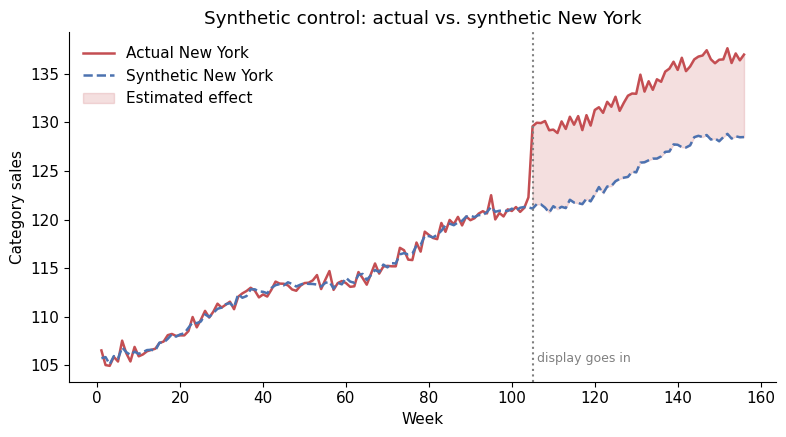

In [9]:
# Actual vs synthetic New York; the post-display gap is the estimated effect.
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(weeks, new_york, color="#C44E52", lw=1.8, label="Actual New York")
ax.plot(weeks, synthetic, color="#4C72B0", lw=1.8, ls="--", label="Synthetic New York")
ax.fill_between(weeks[~pre], synthetic[~pre], new_york[~pre], color="#C44E52", alpha=0.18,
                label="Estimated effect")
ax.axvline(DISPLAY_WEEK, color="gray", ls=":", lw=1.5)
ax.annotate("display goes in", xy=(DISPLAY_WEEK, ax.get_ylim()[0] + 2),
            xytext=(DISPLAY_WEEK + 1, ax.get_ylim()[0] + 2), fontsize=9, color="gray")
ax.set_xlabel("Week")
ax.set_ylabel("Category sales")
ax.set_title("Synthetic control: actual vs. synthetic New York")
ax.legend(loc="upper left", frameon=False)
fig.tight_layout()

The synthetic control tracks New York tightly before the display (low pre-period
RMSE), then the actual series pulls away — and the average post gap recovers the lift
we planted. Most of the weight lands on the three stores New York was built from, with
a few percent spread over others: with 99 donors and two years of pre-period, more than
one blend fits nearly as well, which is normal. When the pre-period fit is poor, the
separation afterward is not trustworthy, which is why a tight pre-fit is the
precondition for reading anything into the post gap.

In [10]:
print("Done — RDD, DiD, and Synthetic Control estimates all recover their planted effects.")

Done — RDD, DiD, and Synthetic Control estimates all recover their planted effects.
